# **Netflix Recommendation Engine**

**What are Recommender Systems?**

Recommender systems are algorithms designed to suggest relevant items to users. These systems are used in various domains such as e-commerce, streaming services, and social media. They enhance user experience by filtering vast amounts of information to deliver personalized content.

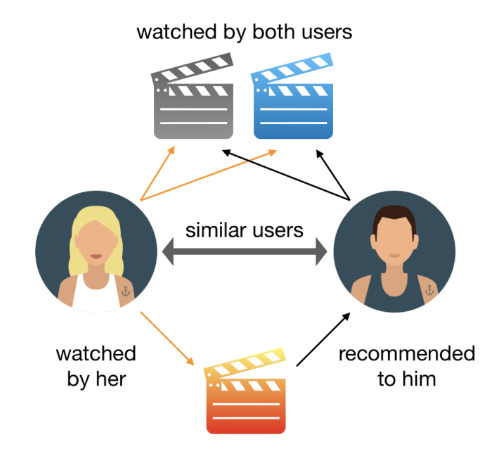

SVD (Singular Value Decomposition) in a recommendation system works by finding patterns in user preferences and item similarities.

Here's a basic idea without going deep into the topic

**1) What the System Has: A big table (matrix) with users on one side and items (like movies) on the other. Users give ratings to items, but not everyone has rated everything**

**2) What SVD Does: SVD looks at the ratings that are available and tries to figure out the hidden connections between users and items. It learns what kind of movies users like based on their previous ratings**

**3) How It Helps: Once SVD understands these patterns, it can predict how a user might rate a movie they haven’t seen yet. Based on these predictions, the system recommends movies that the user is most likely to enjoy**

**In simple terms:**

**Think of SVD as a way to summarize the information in a matrix by identifying its key components.**

**It reduces a high-dimensional matrix into smaller dimensions while preserving the most important patterns in the data.**

# How Does SVD Work?

**Imagine you have a big dataset in the form of a matrix. The goal of SVD is to represent this matrix as the product of three simpler matrices:**

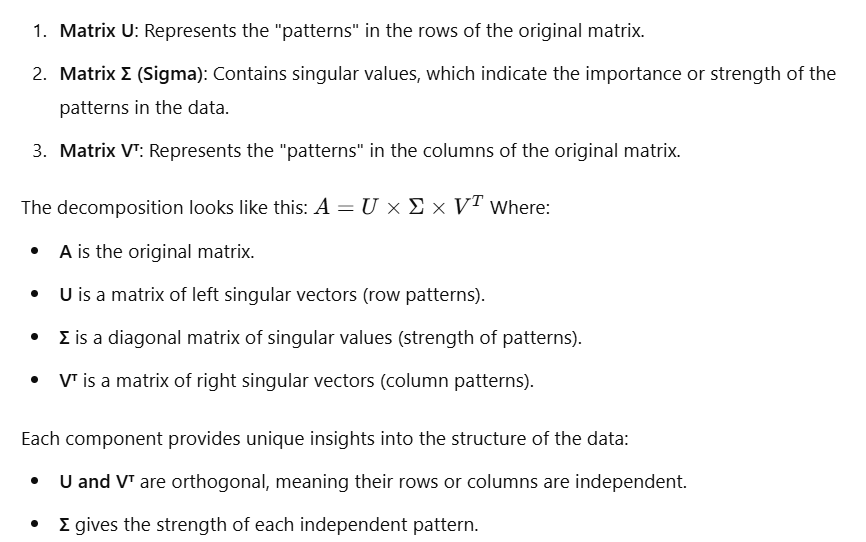

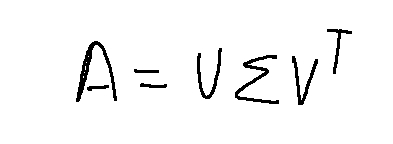

# Step-by-Step Intuition

Let’s use an example of movie ratings to break it down:

Input Matrix: Imagine you have a matrix of users and their ratings for movies. Each cell represents how much a user liked a movie.

**Decomposition:**

U: Groups users into patterns based on their rating preferences (e.g., users who like action movies).

Σ: Identifies how strong or dominant each pattern is (e.g., how many users follow a particular preference).

Vᵀ: Groups movies into patterns based on the ratings they received (e.g., movies in the action genre are liked by similar users).

**Reconstruction:**

 By multiplying U, Σ, and Vᵀ, you can recreate the original matrix. However, you can also keep only the top patterns (largest singular values in Σ) to reduce noise and focus on the most important information.

In [37]:
!pip uninstall -y numpy                             
!pip install numpy==1.26.4                           
!pip install scikit-surprise --prefer-binary   

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4


You can safely remove it manually.
You can safely remove it manually.


  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


  Using cached scikit_surprise-1.1.4.tar.gz (154 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Failed to build scikit-surprise


  error: subprocess-exited-with-error
  
  × Building wheel for scikit-surprise (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [155 lines of output]
      C:\Users\sahaj\AppData\Local\Temp\pip-build-env-9a2db5mt\overlay\Lib\site-packages\setuptools\config\_apply_pyprojecttoml.py:82: SetuptoolsDeprecationWarning: `project.license` as a TOML table is deprecated
      !!
      
              ********************************************************************************
              Please use a simple string containing a SPDX expression for `project.license`. You can also use `project.license-files`. (Both options available on setuptools>=77.0.0).
      
              By 2027-Feb-18, you need to update your project and remove deprecated calls
              or your builds will no longer be supported.
      
              See https://packaging.python.org/en/latest/guides/writing-pyproject-toml/#license for details.
              ****************************************

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Dataset - https://drive.google.com/file/d/17Edh0y88Z2c6MLSwlswQcWNEh3McjIYe/view

netflix_dataset = pd.read_csv('netflix_data.txt',header = None, names = ['Cust_Id', 'Rating'], usecols = [0,1])
netflix_dataset

,Cust_Id,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0
...,...,...
24058258,2591364,2.0
24058259,1791000,2.0
24058260,512536,5.0
24058261,988963,3.0


## EDA

In [40]:
netflix_dataset.head()

,Cust_Id,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0


In [41]:
netflix_dataset.tail()

,Cust_Id,Rating
24058258,2591364,2.0
24058259,1791000,2.0
24058260,512536,5.0
24058261,988963,3.0
24058262,1704416,3.0


In [42]:
netflix_dataset.dtypes

Cust_Id     object
Rating     float64
dtype: object

In [43]:
#Total number of movies
movie_count = netflix_dataset.isnull().sum()
movie_count = movie_count["Rating"]
print("Total number of movies : ",movie_count)


Total number of movies :  4499


In [44]:
#Unique users
customer_count = netflix_dataset['Cust_Id'].nunique()
customer_count = customer_count - movie_count
print("Total number of unique users : ", customer_count)

Total number of unique users :  470758


In [45]:
#Total number of ratings given by the customers to all movies combined
rating_count = netflix_dataset['Cust_Id'].count()-movie_count 
print('Total number of ratings : ', rating_count)

Total number of ratings :  24053764


In [46]:
#Total number of customer have rated movies as 1,2,3,4,5 stars
stars = netflix_dataset.groupby('Rating')['Rating'].agg(['count'])
stars

,count
Rating,
1.0,1118186
2.0,2439073
3.0,6904181
4.0,8085741
5.0,5506583


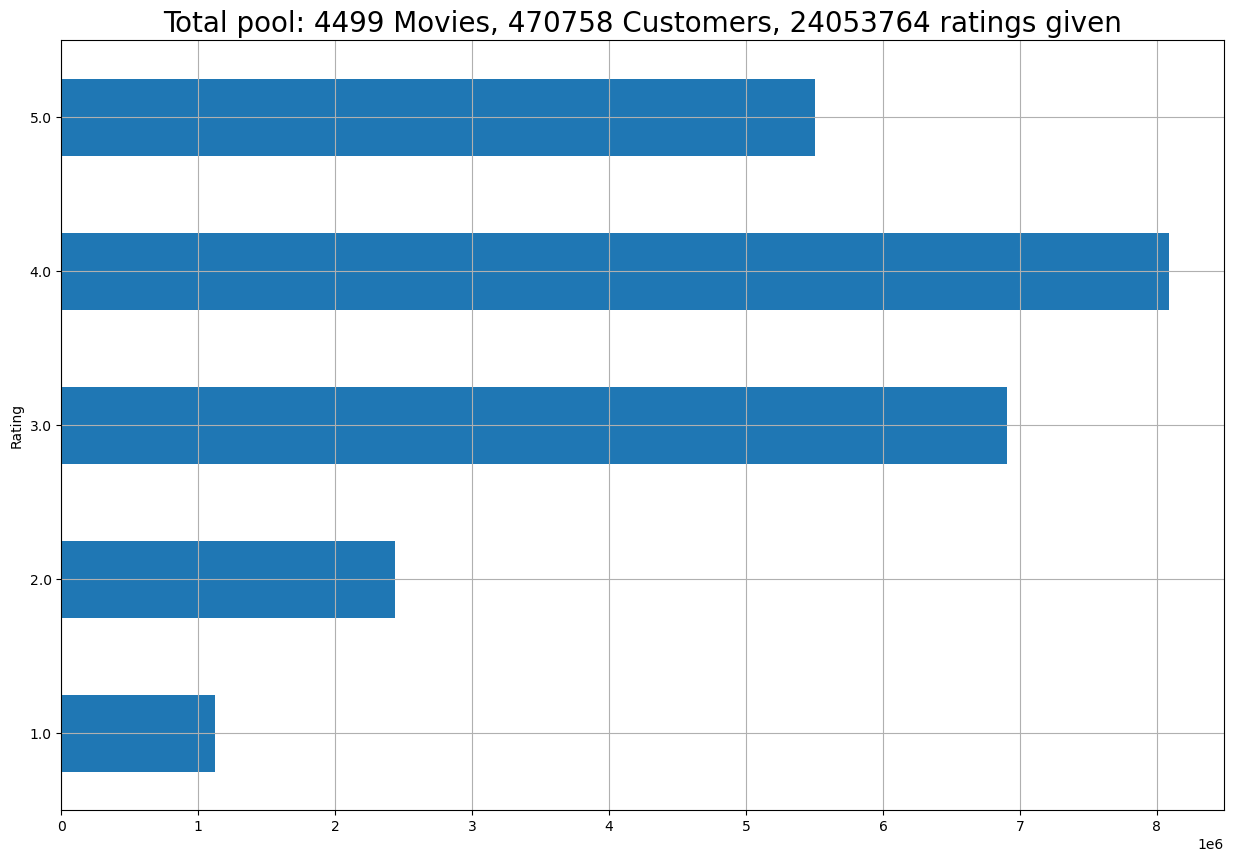

In [47]:
ax=stars.plot(kind='barh', legend=False, figsize=(15,10))

plt.title(f'Total pool: {movie_count} Movies, {customer_count} Customers, {rating_count} ratings given', fontsize=20)
plt.grid(True)

In [48]:
# Lets just make a clear dataframe to find how many MovieId are there
movie_id=None
movie_np =[]
# Iterate over the DataFrame rows
for cust_id in netflix_dataset['Cust_Id']:
    if ':' in cust_id:
      # Update the current movie ID
      movie_id = int(cust_id.replace(':', ''))
    movie_np.append(movie_id)

In [49]:
# Add the new column to the DataFrame
netflix_dataset['Movie_Id'] = movie_np

In [50]:
netflix_dataset

,Cust_Id,Rating,Movie_Id
0,1:,NaN,1
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
...,...,...,...
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499


In [51]:
# to keep only the rows where the 'Rating' column is not null (i.e., it excludes rows where the 'Rating' is NaN)
netflix_dataset = netflix_dataset[netflix_dataset['Rating'].notna()]

In [52]:
netflix_dataset

,Cust_Id,Rating,Movie_Id
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
5,823519,3.0,1
...,...,...,...
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499


In [53]:
netflix_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Cust_Id   object 
 1   Rating    float64
 2   Movie_Id  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 734.1+ MB


In [54]:
#Now we can make cust_id as int datatype
netflix_dataset["Cust_Id"]=netflix_dataset["Cust_Id"].astype(int)

C:\Users\sahaj\AppData\Local\Temp\ipykernel_33256\2301494386.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  netflix_dataset["Cust_Id"]=netflix_dataset["Cust_Id"].astype(int)


In [55]:
netflix_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Cust_Id   int32  
 1   Rating    float64
 2   Movie_Id  int64  
dtypes: float64(1), int32(1), int64(1)
memory usage: 642.3 MB


In [56]:
dataset_movie_summary=netflix_dataset.groupby('Movie_Id')['Rating'].agg(["count"])
dataset_movie_summary

,count
Movie_Id,
1,547
2,145
3,2012
4,142
5,1140
...,...
4495,614
4496,9519
4497,714


In [57]:
#pre-filtering
#remove all the users that have rated less movies and
#also all those movies that has been rated less in numbers

In [58]:
#now we will create a benchmark - to delete data
movie_benchmark=round(dataset_movie_summary['count'].quantile(0.6),0)
movie_benchmark

908.0

In [59]:
drop_movie_list=dataset_movie_summary[dataset_movie_summary['count']<movie_benchmark].index
drop_movie_list  # In this lst all movies are there those are having less rating then benchmark so remove them

Index([   1,    2,    4,    7,    9,   10,   11,   12,   13,   14,
       ...
       4480, 4481, 4486, 4487, 4491, 4494, 4495, 4497, 4498, 4499],
      dtype='int64', name='Movie_Id', length=2699)

In [60]:
len(drop_movie_list)

2699

In [61]:
#now we will remove all the users that are in-active
dataset_cust_summary=netflix_dataset.groupby('Cust_Id')['Rating'].agg(["count"])
dataset_cust_summary

,count
Cust_Id,
6,153
7,195
8,21
10,49
25,4
...,...
2649404,12
2649409,10
2649421,3


In [62]:
cust_benchmark=round(dataset_cust_summary['count'].quantile(0.6),0)
cust_benchmark

36.0

In [63]:
drop_cust_list=dataset_cust_summary[dataset_cust_summary['count']<cust_benchmark].index
drop_cust_list

Index([      8,      25,      33,      83,      94,     126,     130,     133,
           142,     149,
       ...
       2649337, 2649343, 2649351, 2649376, 2649379, 2649384, 2649401, 2649404,
       2649409, 2649421],
      dtype='int32', name='Cust_Id', length=282042)

In [64]:
len(drop_cust_list)

282042

In [65]:
netflix_dataset=netflix_dataset[~netflix_dataset['Movie_Id'].isin(drop_movie_list)]
netflix_dataset=netflix_dataset[~netflix_dataset['Cust_Id'].isin(drop_cust_list)]
print('After the triming, the shape is: {}'.format(netflix_dataset.shape))

After the triming, the shape is: (19695836, 3)


In [66]:
netflix_dataset 

,Cust_Id,Rating,Movie_Id
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
700,656399,4.0,3
...,...,...,...
24056842,1055714,5.0,4496
24056843,2643029,4.0,4496
24056844,267802,4.0,4496
24056845,1559566,3.0,4496


In [67]:
netflix_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19695836 entries, 696 to 24056846
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Cust_Id   int32  
 1   Rating    float64
 2   Movie_Id  int64  
dtypes: float64(1), int32(1), int64(1)
memory usage: 525.9 MB


In [68]:
df_title = pd.read_csv("movie_titles.csv",   encoding='latin',header=None, usecols=[0,1,2], names=['Movie_Id','Year','Name' ])

In [69]:
df_title

,Movie_Id,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


## Model Building

In [72]:
!pip install surprise

In [73]:
from surprise import Reader, Dataset, SVD
from surprise.model_selection import cross_validate

In [74]:
reader=Reader()

In [75]:
#we only work with top 100K rows for quick runtime
data=  Dataset.load_from_df(netflix_dataset[['Cust_Id','Movie_Id','Rating']][:100000], reader)

In [76]:
#Creating a SVD Model
model = SVD()

In [77]:
#Trained model
cross_validate(model, data, measures=['RMSE'], cv=3)

{'test_rmse': array([1.01707021, 1.02138313, 1.01708581]),
 'fit_time': (0.6101424694061279, 0.587862491607666, 0.6188654899597168),
 'test_time': (0.12454915046691895, 0.09916949272155762, 0.10461688041687012)}

# Use Model for Recommendation

In [78]:
netflix_dataset

,Cust_Id,Rating,Movie_Id
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
700,656399,4.0,3
...,...,...,...
24056842,1055714,5.0,4496
24056843,2643029,4.0,4496
24056844,267802,4.0,4496
24056845,1559566,3.0,4496


In [80]:
# Filter the dataset for the specific user
user_ratings = netflix_dataset[netflix_dataset['Cust_Id'] == 1331154]
user_ratings

,Cust_Id,Rating,Movie_Id
697,1331154,4.0,3
5178,1331154,4.0,8
31460,1331154,3.0,18
92840,1331154,4.0,30
224761,1331154,3.0,44
...,...,...,...
23439584,1331154,4.0,4389
23546489,1331154,2.0,4402
23649431,1331154,4.0,4432
23844441,1331154,3.0,4472


In [81]:
# Find the number of unique movies rated by the user
movies_rated_by_user = user_ratings['Movie_Id'].nunique()

print(f"User 1331154 has rated {movies_rated_by_user} unique movies.")

User 1331154 has rated 253 unique movies.


In [82]:
#making a copy for each individual customer for the recomendation
copy_data_for_user = df_title.copy()   
copy_data_for_user

,Movie_Id,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [83]:
 # Removing the movie les then benchmark for this user

CLEAN_copy_data_for_user = copy_data_for_user[~copy_data_for_user['Movie_Id'].isin(drop_movie_list)]
CLEAN_copy_data_for_user  

,Movie_Id,Year,Name
2,3,1997.0,Character
4,5,2004.0,The Rise and Fall of ECW
5,6,1997.0,Sick
7,8,2004.0,What the #$*! Do We Know!?
15,16,1996.0,Screamers
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [84]:
# predict the score (rating) that a user (with user ID 1331154) might give to a list of movies.
CLEAN_copy_data_for_user['Estimate_Score']=CLEAN_copy_data_for_user['Movie_Id'].apply(lambda x: model.predict(1331154, x).est)

C:\Users\sahaj\AppData\Local\Temp\ipykernel_33256\263659698.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  CLEAN_copy_data_for_user['Estimate_Score']=CLEAN_copy_data_for_user['Movie_Id'].apply(lambda x: model.predict(1331154, x).est)


In [85]:
CLEAN_copy_data_for_user

,Movie_Id,Year,Name,Estimate_Score
2,3,1997.0,Character,3.718790
4,5,2004.0,The Rise and Fall of ECW,4.012088
5,6,1997.0,Sick,3.014495
7,8,2004.0,What the #$*! Do We Know!?,3.713208
15,16,1996.0,Screamers,3.228763
...,...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...,3.566851
17766,17767,2004.0,Fidel Castro: American Experience,3.566851
17767,17768,2000.0,Epoch,3.566851
17768,17769,2003.0,The Company,3.566851


In [86]:
CLEAN_copy_data_for_user.sort_values('Estimate_Score', ascending=False)

,Movie_Id,Year,Name,Estimate_Score
24,25,1997.0,Inspector Morse 31: Death Is Now My Neighbour,4.015596
4,5,2004.0,The Rise and Fall of ECW,4.012088
17,18,1994.0,Immortal Beloved,3.883299
2,3,1997.0,Character,3.718790
7,8,2004.0,What the #$*! Do We Know!?,3.713208
...,...,...,...,...
16,17,2005.0,7 Seconds,3.265070
15,16,1996.0,Screamers,3.228763
5,6,1997.0,Sick,3.014495
23,24,1981.0,My Bloody Valentine,2.869655


In [87]:
top5_movies=CLEAN_copy_data_for_user.sort_values('Estimate_Score', ascending=False).head(5)

In [88]:
top5_movies

,Movie_Id,Year,Name,Estimate_Score
24,25,1997.0,Inspector Morse 31: Death Is Now My Neighbour,4.015596
4,5,2004.0,The Rise and Fall of ECW,4.012088
17,18,1994.0,Immortal Beloved,3.883299
2,3,1997.0,Character,3.718790
7,8,2004.0,What the #$*! Do We Know!?,3.713208
